# 2D Continuous Shear-Wave Decay - D2V17

In the **Lattice Boltzmann Method (LBM)**, **Galilean invariance** means that the macroscopic equations recovered by the method should not depend on the constant velocity of the observer/reference frame.

For example, suppose you have a flow field

$$
\mathbf{u}(\mathbf{x},t).
$$

Now imagine observing exactly the same physical system from a frame moving with a constant velocity \(\mathbf{U}_0\). The transformed velocity is

$$
\mathbf{u}'=\mathbf{u}-\mathbf{U}_0.
$$

A Galilean-invariant numerical method should predict the same physical behavior in both frames.

For the Navier–Stokes equations, the transformation is

$$
\mathbf{x}'=\mathbf{x}-\mathbf{U}_0t, \qquad t'=t, \qquad \mathbf{u}'=\mathbf{u}-\mathbf{U}_0,
$$

and the equations retain the same form. Ideally, the LBM should recover this property as well.

The issue is that standard LBM is only **approximately Galilean invariant**. Consider the discrete Boltzmann equation

$$
f_i(\mathbf{x}+\mathbf{c}_i\Delta t,t+\Delta t)-f_i(\mathbf{x},t)=\Omega_i.
$$

For BGK,

$$
\Omega_i=-\frac{1}{\tau} \left( f_i-f_i^{eq}\right),
$$

with the common second-order equilibrium

$$
f_i^{eq}=w_i \rho \left[ 1+ \frac{\mathbf{c}_i\cdot\mathbf{u}}{c_s^2} + \frac{(\mathbf{c}_i\cdot\mathbf{u})^2}{2c_s^4} - \frac{\mathbf{u}^2}{2c_s^2} \right].
$$

This equilibrium is obtained from a low-Mach-number expansion of the Maxwell-Boltzmann distribution. It is truncated at second order in velocity. That truncation is one of the main reasons standard LBM does not possess exact Galilean invariance.

### Where the error appears

The Navier–Stokes momentum equation should be

$$
\partial_t(\rho\mathbf{u}) + \nabla\cdot(\rho\mathbf{u}\mathbf{u}) = -\nabla p + \nabla \cdot \left[ \rho \nu \left( \nabla\mathbf{u} + \nabla\mathbf{u}^{T} \right) \right].
$$

A Chapman–Enskog expansion of a standard lattice such as D2Q9 or D3Q19 produces this equation plus higher-order errors. Some of these errors depend explicitly on the absolute velocity \(\mathbf{u}\), typically through terms of order

$$
O(Ma^3),
$$

where

$$
Ma=\frac{|\mathbf{u}|}{c_s}.
$$

Schematically, you can get corrections such as

$$
\nabla\cdot\left(\rho\,\mathbf{u}\mathbf{u}\mathbf{u}\right),
$$

or related cubic-velocity contributions.

These are often called **cubic velocity errors** or **Galilean invariance errors**.

A particularly intuitive consequence is that the apparent viscosity can become dependent on the background velocity:

$$
\nu_{\mathrm{eff}}=\nu+\Delta\nu(\mathbf{U}_0).
$$

Physically, that should not happen.

### Simple example (Continuous Shear Wave Decay)

Imagine a shear wave

$$
u_x(y)=A\sin(ky).
$$

Without a background flow, its decay is approximately

$$
A(t)=A_0 e^{-\nu k^2t}.
$$

Now add a uniform translation,

$$
u_x(y)=U_0+A\sin(ky).
$$

In the continuous Navier–Stokes equations, the uniform velocity \(U_0\) should **not change the viscous decay rate**. You should still obtain

$$
A(t)=A_0 e^{-\nu k^2t}.
$$

If an LBM simulation instead gives

$$
A(t) \approx A_0e^{-\nu_{\mathrm{eff}}(U_0)k^2t},
$$

with

$$
\nu_{\mathrm{eff}}(U_0)\neq \nu,
$$

then you are observing a Galilean-invariance defect.

This is actually a very useful numerical test.



In [21]:
import numpy as np
import matplotlib.pylab as plt
from IPython.display import display, Math
import time
# =========================================================================================
# Domain
# =========================================================================================
Nx = 1
Ny = 40
# =========================================================================================
# D2V17 lattice
# =========================================================================================
sqrt193 = np.sqrt(193.0)
w0 = (575.0 + 193.0*sqrt193) / 8100.0
w1 = (3355.0 - 91.0*sqrt193) / 18000.0
w2 = (655.0 + 17.0*sqrt193) / 27000.0
w3 = (685.0 - 49.0*sqrt193) / 54000.0
w4 = (1445.0 - 101.0*sqrt193) / 162000.0
w = np.array([w0, w1, w1, w1, w1, w2, w2, w2, w2, w3, w3, w3, w3, w4, w4, w4, w4],dtype="float64")
cx = np.array([0, 1,  0, -1,  0, 1, -1, -1,  1, 2, -2, -2,  2, 3,  0, -3,  0],dtype="int8")
cy = np.array([0, 0,  1,  0, -1, 1,  1, -1, -1, 2,  2, -2, -2, 0,  3,  0, -3],dtype="int8")
Q = 17
# =========================================================================================
# D2V17 lattice sound speed
# =========================================================================================
# cs^2 = sum_i w_i c_ix^2
# =========================================================================================
cs2 = np.sum(w * cx.astype("float64")**2)
cs = np.sqrt(cs2)
print("Sum weights =", np.sum(w))
print("cs^2        =", cs2)
print("cs          =", cs)
# =========================================================================================
# Physical parameters
# =========================================================================================
ho = 1.0
nuo = 0.01
# Shear-wave parameters
A0_phys = 0.05
U0_phys = 0.10*1/10
m_waves = 1
# =========================================================================================
# Scaling
# =========================================================================================
dx = ho / Ny
r = 2.0**3
dt = dx / r
# Lattice viscosity
nu = dt * nuo / dx**2
# Lattice velocities
A0 = dt * A0_phys / dx
U0 = dt * U0_phys / dx
# BGK relaxation time
tau = nu / cs2 + 0.5
rhoi = 1.0
mstep = 3000
display(Math(r"\tau=" + str(tau) + r"\qquad \nu=" + str(nu)))
display(Math(r"c_s=" + str(cs) + r"\qquad c_s^2=" + str(cs2)))
display(Math(r"A_0=" + str(A0) + r"\qquad U_0=" + str(U0)))
display(Math(r"dx=" + str(dx) + r"\qquad dt=" + str(dt)))
# =========================================================================================
# Arrays
# =========================================================================================
rho = np.zeros((Nx, Ny), dtype="float64")
Vx = np.zeros((Nx, Ny), dtype="float64")
Vy = np.zeros((Nx, Ny), dtype="float64")
f = np.zeros((Q, Nx, Ny), dtype="float64")
fp = np.zeros((Q, Nx, Ny), dtype="float64")
feq = np.zeros((Q, Nx, Ny), dtype="float64")
Amplitude = np.zeros(mstep, dtype="float64")
Mass = np.zeros(mstep, dtype="float64")
# Optional storage of sine and cosine coefficients
Amplitude_sin = np.zeros(mstep, dtype="float64")
Amplitude_cos = np.zeros(mstep, dtype="float64")
# =========================================================================================
# Initial condition
# =========================================================================================
xi = np.arange(Nx, dtype="float64") + 0.5
yi = np.arange(Ny, dtype="float64") + 0.5
Xi, Yi = np.meshgrid(xi,yi,indexing="ij")
# Wave number
k = 2.0 * np.pi * m_waves / Ny
rho[:, :] = rhoi
# =========================================================================================
# Shear wave + Galilean translation
# =========================================================================================
# ux = U0 + A0 sin(k y)
# uy = U0
# Because uy != 0, the profile moves along y.
# =========================================================================================
Vx[:, :] = U0 + A0 * np.sin(k * Yi)
Vy[:, :] = U0
# =========================================================================================
# Third-order equilibrium distribution
# =========================================================================================
for i in range(Q):
    cu = cx[i] * Vx + cy[i] * Vy
    u2 = Vx**2 + Vy**2
    f[i, :, :] = (w[i] * rho * (1.0 + cu / cs2 + (cu**2 - cs2*u2) / (2.0*cs2**2) + (cu**3 - 3.0*cs2*u2*cu) / (6.0*cs2**3)))
# =========================================================================================
# Fourier basis
# =========================================================================================
sin_mode = np.sin(k * yi)
cos_mode = np.cos(k * yi)
sin_norm = np.sum(sin_mode**2)
cos_norm = np.sum(cos_mode**2)
# =========================================================================================
# Main loop
# =========================================================================================
start = time.time()
for kk in range(mstep):
    # -------------------------------------------------------------------------------------
    # Collision
    # -------------------------------------------------------------------------------------
    for i in range(Q):
        cu = cx[i] * Vx + cy[i] * Vy
        u2 = Vx**2 + Vy**2
        feq[i, :, :] = w[i] * rho * (1.0 + cu / cs2 + (cu**2 - cs2*u2) / (2.0*cs2**2) + (cu**3 - 3.0*cs2*u2*cu) / (6.0*cs2**3))
        fp[i, :, :] = f[i, :, :] - (1.0/tau)* (f[i, :, :]- feq[i, :, :])
    # -------------------------------------------------------------------------------------
    # Streaming
    # -------------------------------------------------------------------------------------
    for i in range(Q):
        f[i, :, :] = np.roll(np.roll(fp[i, :, :],cx[i],axis=0),cy[i],axis=1)
    # -------------------------------------------------------------------------------------
    # Macroscopic variables
    # -------------------------------------------------------------------------------------
    rho = np.sum(f,axis=0)
    Vx = np.einsum("i,ixy->xy",cx,f) / rho
    Vy = np.einsum("i,ixy->xy",cy,f) / rho
    # -------------------------------------------------------------------------------------
    # Mass
    # -------------------------------------------------------------------------------------
    Mass[kk] = np.mean(rho)
    # =====================================================================================
    # Shear-wave amplitude
    # =====================================================================================
    # Since Vy = U0, the wave translates:
    # ux(y,t) ~ A(t) sin(k y - omega t)
    # therefore:
    # ux = As sin(k y) + Ac cos(k y)
    # and the actual amplitude is:
    # A = sqrt(As^2 + Ac^2)
    # =====================================================================================
    ux_mean_x = np.mean(Vx,axis=0)
    # Remove uniform velocity
    ux_perturbation = (ux_mean_x - np.mean(ux_mean_x))
    # Sine Fourier coefficient
    A_sin = (np.sum(ux_perturbation* sin_mode)/ sin_norm)
    # Cosine Fourier coefficient
    A_cos = (np.sum(ux_perturbation* cos_mode)/ cos_norm)
    Amplitude_sin[kk] = A_sin
    Amplitude_cos[kk] = A_cos
    # Phase-independent amplitude
    Amplitude[kk] = np.sqrt(A_sin**2 + A_cos**2)
    if kk % 200 == 0:
        print(f"step = {kk:5d} "f"A = {Amplitude[kk]:.8e} "f"As = {A_sin:.8e} "f"Ac = {A_cos:.8e} " f"rho = {Mass[kk]:.12f}")
end = time.time()
print()
print("Simulation time =", end - start, "s")

Sum weights = 1.0
cs^2        = 0.3702518670183399
cs          = 0.6084832512225294


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

step =     0 A = 6.22151638e-03 As = 6.22151626e-03 Ac = -1.22158876e-06 rho = 1.000000000000
step =   200 A = 4.86447001e-03 As = 4.86068210e-03 Ac = -1.91932354e-04 rho = 1.000000000000
step =   400 A = 3.79883233e-03 As = 3.78706323e-03 Ac = -2.98796170e-04 rho = 1.000000000000
step =   600 A = 2.96663913e-03 As = 2.94600728e-03 Ac = -3.49269060e-04 rho = 1.000000000000
step =   800 A = 2.31675078e-03 As = 2.28815660e-03 Ac = -3.62868502e-04 rho = 1.000000000000
step =  1000 A = 1.80923056e-03 As = 1.77439745e-03 Ac = -3.53311342e-04 rho = 1.000000000000
step =  1200 A = 1.41289052e-03 As = 1.37378755e-03 Ac = -3.30102083e-04 rho = 1.000000000000
step =  1400 A = 1.10337492e-03 As = 1.06189025e-03 Ac = -2.99708725e-04 rho = 1.000000000000
step =  1600 A = 8.61663519e-04 As = 8.19438512e-04 Ac = -2.66429248e-04 rho = 1.000000000000
step =  1800 A = 6.72902750e-04 As = 6.31265892e-04 Ac = -2.33026791e-04 rho = 1.000000000000
step =  2000 A = 5.25492958e-04 As = 4.85452793e-04 Ac = -2.

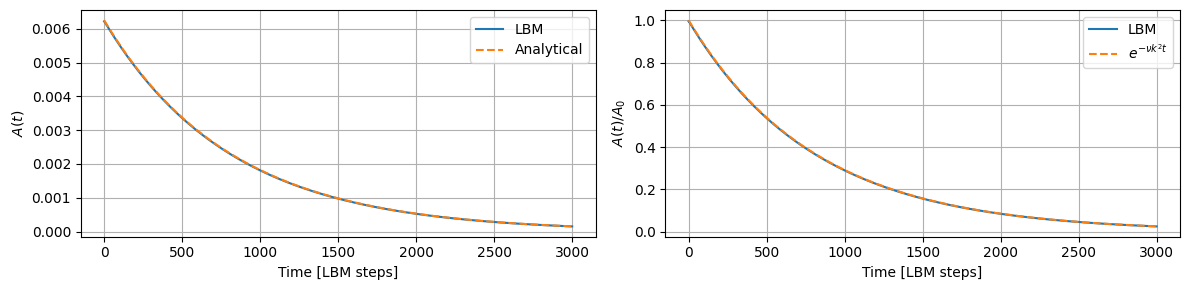

In [22]:
# ==============================Analytical solution===========================================================
time_lbm = np.arange(mstep)
Amplitude_analytical = A0 * np.exp(-nu * k**2 * time_lbm)
# =========================================================================================
# Plot both subplots side by side
# =========================================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
ax1.plot(time_lbm, Amplitude, label="LBM")
ax1.plot(time_lbm, Amplitude_analytical, "--", label="Analytical")
ax1.set_xlabel("Time [LBM steps]")
ax1.set_ylabel(r"$A(t)$")
ax1.legend()
ax1.grid()
ax2.plot(time_lbm, Amplitude / A0, label="LBM")
ax2.plot(time_lbm, np.exp(-nu * k**2 * time_lbm), "--", label=r"$e^{-\nu k^2 t}$")
ax2.set_xlabel("Time [LBM steps]")
ax2.set_ylabel(r"$A(t)/A_0$")
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()


Shear-wave effective viscosity
Nominal viscosity   = 5.000000000000e-02
Effective viscosity = 5.010616812549e-02
Relative error      = 0.212336 %
Background velocity = 1.250000000000e-03
Mach number         = 2.054288260997e-03
Fitting interval    = [100, 2000]


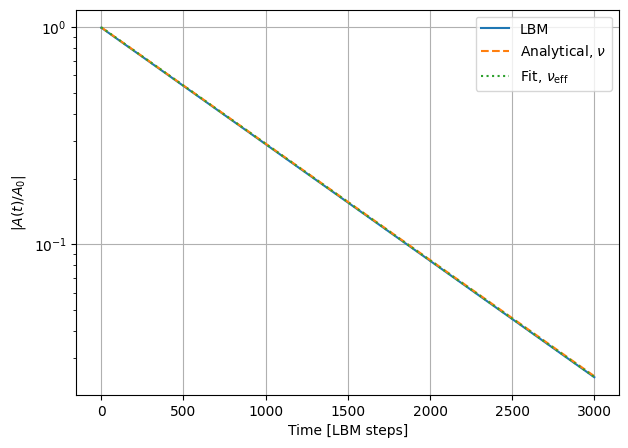

Results saved to "effective_viscosity-nu=0.04999999999999999-U0=0.00125.txt"


In [23]:
# =========================================================================================
# Effective viscosity from shear-wave decay
# =========================================================================================
# Time in lattice units
time_lbm = np.arange(mstep, dtype="float64")
# Avoid numerical problems if amplitude becomes too small or changes sign
valid = Amplitude > 0.0
t_fit = time_lbm[valid]
A_fit = Amplitude[valid]
# -----------------------------------------------------------------------------
# Optional: choose only part of the simulation for fitting
# This helps avoid the initial transient and the very small-amplitude region.
# Example: fit from step 100 to 2000
# -----------------------------------------------------------------------------
fit_start = 100
fit_end   = 2000
mask_fit = ((t_fit >= fit_start) & (t_fit <= fit_end))
t_fit = t_fit[mask_fit]
A_fit = A_fit[mask_fit]
# -----------------------------------------------------------------------------
# Linearized analytical relation
# ln(A/A0) = -nu_eff * k^2 * t
# -----------------------------------------------------------------------------
log_A = np.log(A_fit / A0)
# Linear regression:
# log(A/A0) = slope*t + intercept
slope, intercept = np.polyfit(t_fit,log_A,1)
# Effective viscosity
nu_eff = -slope / k**2
# Relative viscosity error
nu_error = 100.0 * (nu_eff - nu) / nu
print()
print("==============================================")
print("Shear-wave effective viscosity")
print("==============================================")
print(f"Nominal viscosity   = {nu:.12e}")
print(f"Effective viscosity = {nu_eff:.12e}")
print(f"Relative error      = {nu_error:.6f} %")
print(f"Background velocity = {U0:.12e}")
print(f"Mach number         = {U0/cs:.12e}")
print(f"Fitting interval    = [{fit_start}, {fit_end}]")
print("==============================================")
# =========================================================================================
# Fitted curve
# =========================================================================================
Amplitude_fit = A0 * np.exp(-nu_eff * k**2 * time_lbm)
plt.figure(figsize=(7, 5))
plt.semilogy(time_lbm,np.abs(Amplitude / A0),label="LBM")
plt.semilogy(time_lbm,np.exp(-nu * k**2 * time_lbm),"--",label=r"Analytical, $\nu$")
plt.semilogy(time_lbm,np.exp(-nu_eff * k**2 * time_lbm),":",label=r"Fit, $\nu_{\mathrm{eff}}$")
plt.xlabel("Time [LBM steps]")
plt.ylabel(r"$|A(t)/A_0|$")
plt.legend()
plt.grid()
plt.show()
# =========================================================================================
# Save effective viscosity to TXT file
# =========================================================================================
filename = f"effective_viscosity-nu={nu}-U0={U0}.txt"
with open(filename, "w") as file:
    file.write("# Shear-wave Galilean invariance test\n")
    file.write("# -----------------------------------\n")
    file.write(f"Nx                    = {Nx}\n")
    file.write(f"Ny                    = {Ny}\n")
    file.write(f"tau                   = {tau:.16e}\n")
    file.write(f"cs                    = {cs:.16e}\n")
    file.write(f"k                     = {k:.16e}\n")
    file.write(f"A0                    = {A0:.16e}\n")
    file.write(f"U0                    = {U0:.16e}\n")
    file.write(f"Mach                  = {U0/cs:.16e}\n")
    file.write(f"nu_nominal            = {nu:.16e}\n")
    file.write(f"nu_effective          = {nu_eff:.16e}\n")
    file.write(f"relative_error_percent= {nu_error:.16e}\n")
    file.write(f"fit_start             = {fit_start}\n")
    file.write(f"fit_end               = {fit_end}\n")
    file.write(f"slope                 = {slope:.16e}\n")
    file.write(f"intercept             = {intercept:.16e}\n")

print(f'Results saved to "{filename}"')

effective_viscosity-nu=0.04999999999999999-U0=0.00125.txt: nu = 5.00000000e-02, nu_eff = 5.01061681e-02
effective_viscosity-nu=0.04999999999999999-U0=0.012500000000000002.txt: nu = 5.00000000e-02, nu_eff = 5.01061501e-02
effective_viscosity-nu=0.04999999999999999-U0=0.125.txt: nu = 5.00000000e-02, nu_eff = 5.01047076e-02
effective_viscosity-nu=0.09999999999999998-U0=0.0025.txt: nu = 1.00000000e-01, nu_eff = 1.00162162e-01
effective_viscosity-nu=0.09999999999999998-U0=0.025000000000000005.txt: nu = 1.00000000e-01, nu_eff = 1.00162069e-01
effective_viscosity-nu=0.09999999999999998-U0=0.25.txt: nu = 1.00000000e-01, nu_eff = 1.00160029e-01


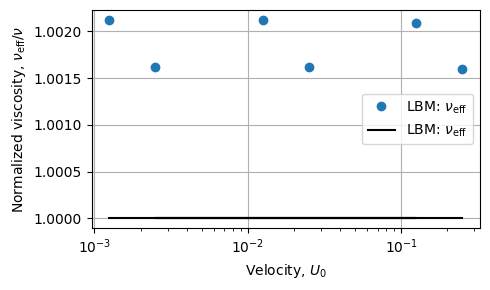

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
# =========================================================================================
# Folder containing the .txt files
# =========================================================================================
folder = Path(".")   # Current directory
files = sorted(folder.glob("*.txt"))
# =========================================================================================
# Arrays for results
# =========================================================================================
U0_all = []
nu_all = []
nu_eff_all = []
error_all = []
filename_all = []
# =========================================================================================
# Read all files
# =========================================================================================
for filename in files:

    data = {}
    with open(filename, "r") as file:
        for line in file:
            line = line.strip()
            # Ignore comments and empty lines
            if not line or line.startswith("#"):
                continue
            # Read lines containing key = value
            if "=" in line:
                key, value = line.split("=", 1)
                key = key.strip()
                value = value.strip()
                try:
                    data[key] = float(value)
                except ValueError:
                    pass
    # -------------------------------------------------------------------------
    # Check whether the required quantities exist
    # -------------------------------------------------------------------------
    if "nu_nominal" in data and "nu_effective" in data:
        nu_all.append(data["nu_nominal"])
        nu_eff_all.append(data["nu_effective"])
        filename_all.append(filename.name)
        # Optional quantities
        U0_all.append(data.get("U0", np.nan))
        error_all.append(data.get("relative_error_percent", np.nan))
        print(f"{filename.name}: "f"nu = {data['nu_nominal']:.8e}, "f"nu_eff = {data['nu_effective']:.8e}")

# Convert to numpy arrays
nu_all = np.array(nu_all)
nu_eff_all = np.array(nu_eff_all)
U0_all = np.array(U0_all)
error_all = np.array(error_all)
# =========================================================================================
# Sort results according to nominal viscosity
# =========================================================================================
order = np.argsort(nu_all)
nu_all = nu_all[order]
nu_eff_all = nu_eff_all[order]
U0_all = U0_all[order]
error_all = error_all[order]
# =========================================================================================
# Plot: effective viscosity vs nominal viscosity
# =========================================================================================
plt.figure(figsize=(5, 3))
# plt.plot(nu_all,nu_eff_all,"o-",label=r"LBM: $\nu_{\mathrm{eff}}$")
# plt.plot(nu_all,nu_eff_all/nu_all,"o",label=r"LBM: $\nu_{\mathrm{eff}}$")
plt.plot(U0_all,nu_eff_all/nu_all,"o",label=r"LBM: $\nu_{\mathrm{eff}}$")
# -----------------------------------------------------------------------------
# Perfect agreement line: nu_eff = nu
# -----------------------------------------------------------------------------
nu_min = min(np.min(nu_all), np.min(nu_eff_all))
nu_max = max(np.max(nu_all), np.max(nu_eff_all))

# plt.plot([nu_min, nu_max],[nu_min, nu_max],"--",label=r"$\nu_{\mathrm{eff}}=\nu$")
# plt.plot([nu_min, nu_max],[nu_min*0+1, nu_max*0+1],"--",label=r"$\nu_{\mathrm{eff}}=\nu$")
plt.semilogx(U0_all,nu_eff_all/nu_all*0+1,"k-",label=r"LBM: $\nu_{\mathrm{eff}}$")
plt.xlabel(r"Velocity, $U_{0}$")
plt.ylabel(r"Normalized viscosity, $\nu_{\mathrm{eff}}/\nu$")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# 2D Discontinuous Shear-Wave Decay

Yes. A useful discontinuous shear-wave test is to replace the sinusoidal initial condition

$$
u_x(y,0)=U_0+A_0\sin(ky)
$$

by a square-wave profile,

$$
u_x(y,0)= U_0+
\begin{cases}
+A_0, & 0\le y<L_y/2,\\[2mm]
-A_0, & L_y/2\le y<L_y,
\end{cases} \qquad u_y=0.
$$

Because the domain is periodic, this produces two velocity discontinuities. Viscosity progressively smooths those discontinuities according to

$$
\frac{\partial u_x}{\partial t} = \nu \frac{\partial^2u_x}{\partial y^2}.
$$

The discontinuous profile can be represented analytically by its Fourier series,

$$
u_x(y,t)-U_0 = \frac{4A_0}{\pi} \sum_{n=0}^{\infty} \frac{1}{2n+1} \sin\left[(2n+1)k y\right] e^{-\nu(2n+1)^2k^2t}.
$$


In [39]:
# import numpy as np
# import matplotlib.pylab as plt
# import matplotlib.colors
# from IPython.display import display, Math
# import time
# # ====================================Domain=====================================================
# Nx = 1
# Ny = 40
# # ======================================D2Q9 lattice===================================================
# w0 = 4.0 / 9.0; w1 = 1.0 / 9.0; w2 = 1.0 / 36.0
# w = np.array([w0, w1, w1, w1, w1, w2, w2, w2, w2],dtype="float64")
# cx = np.array([0, 1, 0, -1, 0, 1, -1, -1, 1],dtype="int8")
# cy = np.array([0, 0, 1, 0, -1, 1, 1, -1, -1],dtype="int8")
# cs = 1.0 / np.sqrt(3.0)
# # ===============================Physical parameters==========================================================
# ho = 1.0                      # Physical domain length
# nuo = 0.01                    # Physical kinematic viscosity
# # Shear-wave parameters
# A0_phys = 0.05                # Physical wave amplitude
# U0_phys = 0.10*10/1               # Uniform background velocity
# m_waves = 1                   # Number of wavelengths in y direction
# # ================================caling=========================================================
# dx = ho / Ny
# r = 2.0**(3)                       # r = dx/dt
# dt = dx / r
# # LBM viscosity
# nu = dt * nuo / dx**2
# # Convert velocities to lattice units
# A0 = dt * A0_phys / dx
# U0 = dt * U0_phys / dx
# tau = nu / cs**2 + 0.5
# rhoi = 1.0
# # Simulation time
# mstep = 3000
# display(Math(r"\tau=" + str(tau) + r"\qquad \nu=" + str(nu)))
# display(Math(r"A_0=" + str(A0)+ r"\qquad U_0=" + str(U0)))
# display(Math(r"dx=" + str(dx) + r"\qquad dt=" + str(dt)))
# # ===================================Arrays======================================================
# rho = np.zeros((Nx, Ny), dtype="float64")
# Vx  = np.zeros((Nx, Ny), dtype="float64")
# Vy  = np.zeros((Nx, Ny), dtype="float64")
# f   = np.zeros((9, Nx, Ny), dtype="float64")
# fp  = np.zeros((9, Nx, Ny), dtype="float64")
# feq = np.zeros((9, Nx, Ny), dtype="float64")
# Amplitude = np.zeros(mstep, dtype="float64")
# Mass      = np.zeros(mstep, dtype="float64")
# # ===================================Initial condition======================================================
# xi = np.arange(Nx, dtype="float64") + 0.5
# yi = np.arange(Ny, dtype="float64") + 0.5
# Xi, Yi = np.meshgrid(xi, yi, indexing="ij")
# # Wave number in lattice coordinates
# k = 2.0 * np.pi * m_waves / Ny
# rho[:, :] = rhoi
# # =========================================================================================
# # Initial discontinuous shear wave
# # =========================================================================================
# Vx[:, :] = U0 + np.where(Yi < Ny / 2.0,A0,-A0)
# # Vx[:, :] = np.where(Yi < Ny / 2.0,A0,-A0)
# Vy[:, :] = U0
# # =========================================================================================
# # Fundamental Fourier mode
# # =========================================================================================
# sin_mode = np.sin(k * yi)
# ux_mean_x = np.mean(Vx, axis=0)
# ux_perturbation = ux_mean_x - np.mean(ux_mean_x)
# A1_initial = np.sum(ux_perturbation * sin_mode) / np.sum(sin_mode**2)
# # ================Initialize distributions with second-order equilibrium============================
# for i in range(9):
#     t1 = cx[i] * Vx + cy[i] * Vy
#     f[i, :, :] = w[i] * rho * (1.0 + t1/cs**2 + t1**2/(2.0*cs**4)- (Vx**2+Vy**2)/(2.0*cs**2))
# # ==============================Init-Loop===========================================================
# start = time.time()
# for kk in range(mstep):
#     # -------------------------------------Collision------------------------------------------------
#     for i in range(9):
#         t1 = cx[i] * Vx + cy[i] * Vy
#         feq[i, :, :] = w[i] * rho * (1.0 + t1/cs**2 + t1**2/(2.0*cs**4) - (Vx**2 + Vy**2)/(2.0*cs**2))
#         fp[i, :, :] = (f[i, :, :]- (1.0 / tau) * (f[i, :, :] - feq[i, :, :]))
#     # ------------------------------------Streaming - periodic in both directions-------------------------------------------------
#     for i in range(9):
#         f[i, :, :] = np.roll(np.roll(fp[i, :, :],cx[i],axis=0),cy[i],axis=1)
#     # ----------------------------------Macroscopic variables---------------------------------------------------
#     rho = np.sum(f, axis=0)
# # ==============================Main-Loop===========================================================
# start = time.time()
# for kk in range(mstep):
#     # -------------------------------------Collision------------------------------------------------
#     for i in range(9):
#         t1 = cx[i] * Vx + cy[i] * Vy
#         feq[i, :, :] = w[i] * rho * (1.0 + t1/cs**2 + t1**2/(2.0*cs**4) - (Vx**2 + Vy**2)/(2.0*cs**2))
#         fp[i, :, :] = (f[i, :, :]- (1.0 / tau) * (f[i, :, :] - feq[i, :, :]))
#     # ------------------------------------Streaming - periodic in both directions-------------------------------------------------
#     for i in range(9):
#         f[i, :, :] = np.roll(np.roll(fp[i, :, :],cx[i],axis=0),cy[i],axis=1)
#     # ----------------------------------Macroscopic variables---------------------------------------------------
#     rho = np.sum(f, axis=0)
#     Vx = np.einsum("i,ixy->xy",cx,f) / rho
#     Vy = np.einsum("i,ixy->xy",cy,f) / rho
#     # ---------------------------------Mass----------------------------------------------------
#     Mass[kk] = np.mean(rho)
#     # Remove the uniform velocity U0 and project the velocity field onto sin(k y).
#     # --------------------------------Shear-wave amplitude-----------------------------------------------------
#     ux_mean_x = np.mean(Vx, axis=0)
#     # ux_perturbation = ux_mean_x - np.mean(ux_mean_x)
#     # Amplitude[kk] = (2.0 / Ny* np.sum(ux_perturbation* np.sin(k * yi)))
#     # Remove Galilean background velocity
#     ux_perturbation = ux_mean_x - np.mean(ux_mean_x)
#     Amplitude[kk] = np.sum(ux_perturbation * sin_mode) / np.sum(sin_mode**2)
#     if kk % 200 == 0:
#         print(f"step = {kk:5d} "f"A = {Amplitude[kk]:.8e} "f"rho = {Mass[kk]:.12f}")
# end = time.time()
# print("Simulation time =", end - start, "s")

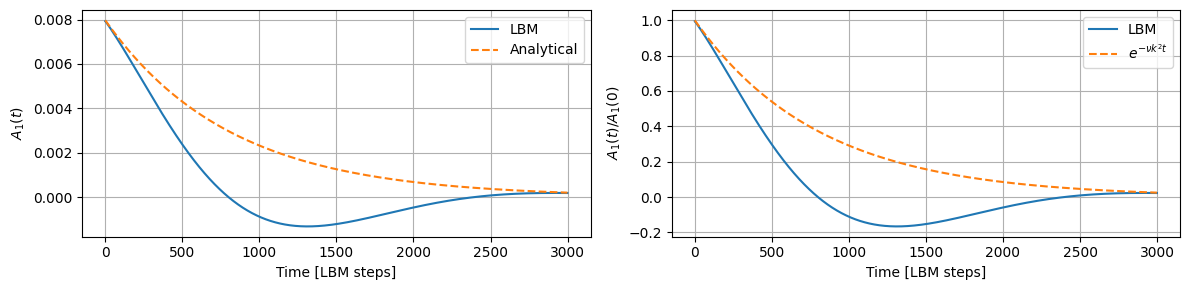

In [40]:
# ==============================Analytical solution===========================================================
time_lbm = np.arange(mstep)
# Fundamental-mode analytical amplitude
Amplitude_analytical = A1_initial * np.exp(-nu * k**2 * time_lbm)
# =========================================================================================
# Plot both subplots side by side
# =========================================================================================
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(12, 3))
# -----------------------------------------------------------------------------------------
# Absolute amplitude
# -----------------------------------------------------------------------------------------
ax1.plot(time_lbm,Amplitude,label="LBM")
ax1.plot(time_lbm,Amplitude_analytical,"--",label="Analytical")
ax1.set_xlabel("Time [LBM steps]")
ax1.set_ylabel(r"$A_1(t)$")
ax1.legend()
ax1.grid()
# -----------------------------------------------------------------------------------------
# Normalized amplitude
# -----------------------------------------------------------------------------------------
ax2.plot(time_lbm,Amplitude / A1_initial,label="LBM")
ax2.plot(time_lbm,Amplitude_analytical / A1_initial,"--",label=r"$e^{-\nu k^2 t}$")
ax2.set_xlabel("Time [LBM steps]")
ax2.set_ylabel(r"$A_1(t)/A_1(0)$")
ax2.legend()
ax2.grid()
plt.tight_layout()
plt.show()


Discontinuous shear-wave effective viscosity
Square-wave amplitude A0   = 6.250000000000e-03
Initial Fourier amplitude  = 7.965934276989e-03
Continuous 4*A0/pi         = 7.957747154595e-03
Nominal viscosity          = 5.000000000000e-02
Effective viscosity        = 2.085818077591e-01
nu_eff / nu                = 4.171636155182e+00
Relative error             = 317.163616 %
Background velocity        = 1.250000000000e-02
Mach number                = 2.054288260997e-02
Fitting interval           = [100, 2000]


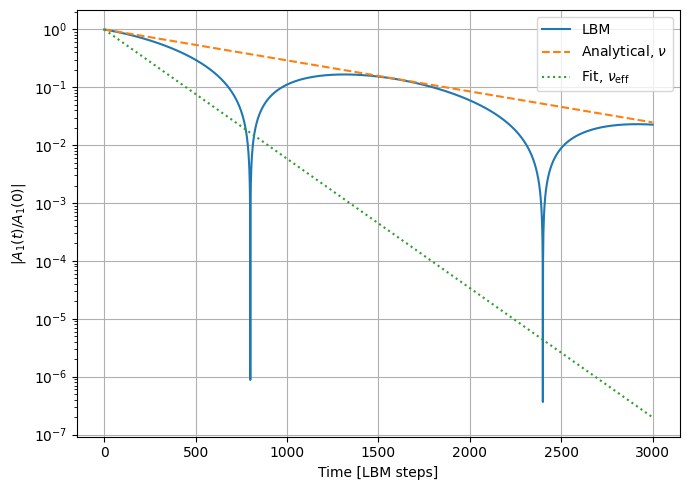

Results saved to "disc-wave/effective_viscosity-nu=5.00000000e-02-U0=1.25000000e-02.txt"


In [41]:
# =========================================================================================
# Effective viscosity from discontinuous shear-wave decay
# =========================================================================================
# Time in lattice units
time_lbm = np.arange(mstep, dtype="float64")
# =========================================================================================
# Fundamental Fourier amplitude
# For the discontinuous square wave:
#     ux - U0 = +/- A0
# the first Fourier coefficient is approximately:
#     A1(0) = 4*A0/pi
# Here we use the discrete value already calculated from the initial condition:
#     A1_initial
# =========================================================================================
# Avoid numerical problems if amplitude becomes too small or changes sign
valid = Amplitude > 0.0
t_fit = time_lbm[valid]
A_fit = Amplitude[valid]
# =========================================================================================
# Choose fitting interval
# =========================================================================================
fit_start = 100
fit_end   = 2000
mask_fit = ((t_fit >= fit_start)& (t_fit <= fit_end))
t_fit = t_fit[mask_fit]
A_fit = A_fit[mask_fit]
# =========================================================================================
# Linearized analytical relation
# A1(t) = A1(0) exp(-nu_eff*k^2*t)
# therefore:
# ln[A1(t)/A1(0)] = -nu_eff*k^2*t
# =========================================================================================
log_A = np.log(A_fit / A1_initial)
# Linear regression:
# log[A1(t)/A1(0)] = slope*t + intercept
slope, intercept = np.polyfit(t_fit,log_A,1)
# =========================================================================================
# Effective viscosity
# =========================================================================================
nu_eff = -slope / k**2
# Relative viscosity error
nu_error = 100.0 * (nu_eff - nu) / nu
# =========================================================================================
# Print results
# =========================================================================================
print()
print("======================================================")
print("Discontinuous shear-wave effective viscosity")
print("======================================================")
print(f"Square-wave amplitude A0   = {A0:.12e}")
print(f"Initial Fourier amplitude  = {A1_initial:.12e}")
print(f"Continuous 4*A0/pi         = {4.0*A0/np.pi:.12e}")
print(f"Nominal viscosity          = {nu:.12e}")
print(f"Effective viscosity        = {nu_eff:.12e}")
print(f"nu_eff / nu                = {nu_eff/nu:.12e}")
print(f"Relative error             = {nu_error:.6f} %")
print(f"Background velocity        = {U0:.12e}")
print(f"Mach number                = {U0/cs:.12e}")
print(f"Fitting interval           = [{fit_start}, {fit_end}]")
print("======================================================")
# =========================================================================================
# Analytical and fitted curves
# =========================================================================================
Amplitude_analytical = (A1_initial * np.exp(-nu * k**2 * time_lbm))
Amplitude_fit = (A1_initial * np.exp(-nu_eff * k**2 * time_lbm))
# =========================================================================================
# Plot
# =========================================================================================
plt.figure(figsize=(7, 5))
plt.semilogy(time_lbm,np.abs(Amplitude / A1_initial),label="LBM")
plt.semilogy(time_lbm,Amplitude_analytical / A1_initial,"--",label=r"Analytical, $\nu$")
plt.semilogy(time_lbm,Amplitude_fit / A1_initial,":",label=r"Fit, $\nu_{\mathrm{eff}}$")
plt.xlabel("Time [LBM steps]")
plt.ylabel(r"$|A_1(t)/A_1(0)|$")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# =========================================================================================
# Save effective viscosity to TXT file
# =========================================================================================

from pathlib import Path
folder = Path("disc-wave")
folder.mkdir(parents=True, exist_ok=True)
filename = folder / (f"effective_viscosity-nu={nu:.8e}-U0={U0:.8e}.txt")

with open(filename, "w") as file:
    file.write("# Discontinuous shear-wave Galilean invariance test\n")
    file.write("# -------------------------------------------------\n")
    file.write(f"Nx                     = {Nx}\n")
    file.write(f"Ny                     = {Ny}\n")
    file.write(f"tau                    = {tau:.16e}\n")
    file.write(f"cs                     = {cs:.16e}\n")
    file.write(f"k                      = {k:.16e}\n")
    # Square-wave amplitude
    file.write(f"A0                     = {A0:.16e}\n")
    # Fundamental Fourier amplitude
    file.write(f"A1_initial             = {A1_initial:.16e}\n")
    file.write(f"A1_continuous          = {4.0*A0/np.pi:.16e}\n")
    file.write(f"U0                     = {U0:.16e}\n")
    file.write(f"Mach                   = {U0/cs:.16e}\n")
    file.write(f"nu_nominal             = {nu:.16e}\n")
    file.write(f"nu_effective           = {nu_eff:.16e}\n")
    file.write(f"nu_eff_over_nu         = {nu_eff/nu:.16e}\n")
    file.write(f"relative_error_percent = {nu_error:.16e}\n")
    file.write(f"fit_start              = {fit_start}\n")
    file.write(f"fit_end                = {fit_end}\n")
    file.write(f"slope                  = {slope:.16e}\n")
    file.write(f"intercept              = {intercept:.16e}\n")

print(f'Results saved to "{filename}"')

effective_viscosity-nu=5.00000000e-02-U0=1.25000000e-02.txt: nu = 5.00000000e-02, nu_eff = 2.08581808e-01
effective_viscosity-nu=5.00000000e-02-U0=1.25000000e-03.txt: nu = 5.00000000e-02, nu_eff = 5.17843104e-02


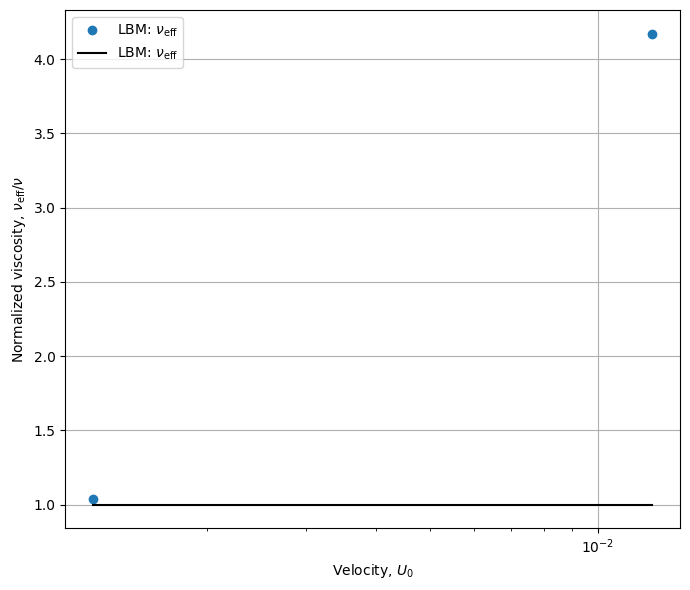

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
# =========================================================================================
# Folder containing the .txt files
# =========================================================================================
folder = Path(".")   # Current directory
files = sorted(folder.glob("disc-wave/*.txt"))
# =========================================================================================
# Arrays for results
# =========================================================================================
U0_all = []
nu_all = []
nu_eff_all = []
error_all = []
filename_all = []
# =========================================================================================
# Read all files
# =========================================================================================
for filename in files:

    data = {}
    with open(filename, "r") as file:
        for line in file:
            line = line.strip()
            # Ignore comments and empty lines
            if not line or line.startswith("#"):
                continue
            # Read lines containing key = value
            if "=" in line:
                key, value = line.split("=", 1)
                key = key.strip()
                value = value.strip()
                try:
                    data[key] = float(value)
                except ValueError:
                    pass
    # -------------------------------------------------------------------------
    # Check whether the required quantities exist
    # -------------------------------------------------------------------------
    if "nu_nominal" in data and "nu_effective" in data:
        nu_all.append(data["nu_nominal"])
        nu_eff_all.append(data["nu_effective"])
        filename_all.append(filename.name)
        # Optional quantities
        U0_all.append(data.get("U0", np.nan))
        error_all.append(data.get("relative_error_percent", np.nan))
        print(f"{filename.name}: "f"nu = {data['nu_nominal']:.8e}, "f"nu_eff = {data['nu_effective']:.8e}")

# Convert to numpy arrays
nu_all = np.array(nu_all)
nu_eff_all = np.array(nu_eff_all)
U0_all = np.array(U0_all)
error_all = np.array(error_all)
# =========================================================================================
# Sort results according to nominal viscosity
# =========================================================================================
order = np.argsort(nu_all)
nu_all = nu_all[order]
nu_eff_all = nu_eff_all[order]
U0_all = U0_all[order]
error_all = error_all[order]
# =========================================================================================
# Plot: effective viscosity vs nominal viscosity
# =========================================================================================
plt.figure(figsize=(7, 6))
# plt.plot(nu_all,nu_eff_all,"o-",label=r"LBM: $\nu_{\mathrm{eff}}$")
# plt.plot(nu_all,nu_eff_all/nu_all,"o",label=r"LBM: $\nu_{\mathrm{eff}}$")
plt.plot(U0_all,nu_eff_all/nu_all,"o",label=r"LBM: $\nu_{\mathrm{eff}}$")
# -----------------------------------------------------------------------------
# Perfect agreement line: nu_eff = nu
# -----------------------------------------------------------------------------
nu_min = min(np.min(nu_all), np.min(nu_eff_all))
nu_max = max(np.max(nu_all), np.max(nu_eff_all))

# plt.plot([nu_min, nu_max],[nu_min, nu_max],"--",label=r"$\nu_{\mathrm{eff}}=\nu$")
# plt.plot([nu_min, nu_max],[nu_min*0+1, nu_max*0+1],"--",label=r"$\nu_{\mathrm{eff}}=\nu$")
plt.semilogx(U0_all,nu_eff_all/nu_all*0+1,"k-",label=r"LBM: $\nu_{\mathrm{eff}}$")
plt.xlabel(r"Velocity, $U_{0}$")
plt.ylabel(r"Normalized viscosity, $\nu_{\mathrm{eff}}/\nu$")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()